# Decoder comparison (d=5, low p): MWPM, CM, Pearl-CM, SAC-GNN, Tesseract

Rotated surface code Z-memory, circuit-level depolarizing, distance 5. Five decoders, restricted to
$p\le 10^{-3}$ and extended down to the lowest $p$ available in each dataset:

| decoder | source | note |
|---|---|---|
| **MWPM** | `alpha_sweep_extended.csv` | uncorrelated baseline |
| **CM (hard, α=1)** | `alpha_sweep_extended.csv` | ordinary correlated matching |
| **Pearl-CM (best α)** | `alpha_sweep_extended.csv` | best α per p (oracle) |
| **SAC-GNN** | `ler_vs_p_slowgpu_v2_..._trial_0040_best.csv` | learned reweighting (`neural`) |
| **Tesseract** | `ler_vs_p_tesseract_d5.csv` | search-based, near-ML |

**Caveat:** the three CSVs are *separate runs* whose MWPM baselines differ by up to ~20% at some p.
So the left panel (raw LER) mixes baselines; the right panel normalises each decoder to **its own
run's MWPM** — the fair cross-run comparison.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
PMAX = 1e-3

# --- alpha sweep: MWPM, CM(alpha=1), Pearl best-alpha (d=5) ---
asw = pd.read_csv(os.path.join(ROOT, "data", "alpha_sweep_extended.csv"))
asw["alpha"] = pd.to_numeric(asw["alpha"], errors="coerce")
d5 = asw[(asw.distance == 5) & (asw.p <= PMAX)]
ps_a = np.array(sorted(d5.p.unique()))
def asw_row(p, dec, alpha=None):
    s = d5
    r = s[(s.decoder == "mwpm") & (s.p == p)] if dec == "mwpm" else \
        s[(s.decoder == "cm") & (s.p == p) & (np.isclose(s.alpha, alpha))]
    return float(r.ler.iloc[0]), float(r.ler_std.iloc[0])
mwpm   = np.array([asw_row(p, "mwpm") for p in ps_a])                # (p,2)
cm     = np.array([asw_row(p, "cm", 1.0) for p in ps_a])
alphas = sorted(d5[d5.decoder == "cm"].alpha.unique())
pearl  = np.array([min((asw_row(p, "cm", a) for a in alphas), key=lambda t: t[0]) for p in ps_a])

# --- SAC-GNN trial: neural vs static(=MWPM) ---
tr = pd.read_csv(os.path.join(ROOT, "data", "ler_vs_p_slowgpu_v2_qec_graph_optuna_run_d5_trial_0040_best.csv"))
tr = tr[tr.p <= PMAX].sort_values("p")
ps_g = tr.p.to_numpy()
gnn = np.c_[tr.neural_mean, tr.neural_std]; gnn_mwpm = tr.static_mean.to_numpy()

# --- Tesseract: tess vs its own mwpm ---
te = pd.read_csv(os.path.join(ROOT, "data", "ler_vs_p_tesseract_d5.csv"))
te = te[te.p <= PMAX].sort_values("p")
ps_t = te.p.to_numpy()
tess = np.c_[te.tess_mean, te.tess_std]; tess_mwpm = te.mwpm_mean.to_numpy()

print("p ranges  (<= 1e-3):")
print("  MWPM/CM/Pearl:", ps_a)
print("  SAC-GNN      :", ps_g)
print("  Tesseract    :", ps_t)

p ranges  (<= 1e-3):
  MWPM/CM/Pearl: [0.0001 0.0002 0.0004 0.0007 0.001 ]
  SAC-GNN      : [0.0002 0.0004 0.0006 0.0008 0.001 ]
  Tesseract    : [0.0002 0.0004 0.0006 0.0008]


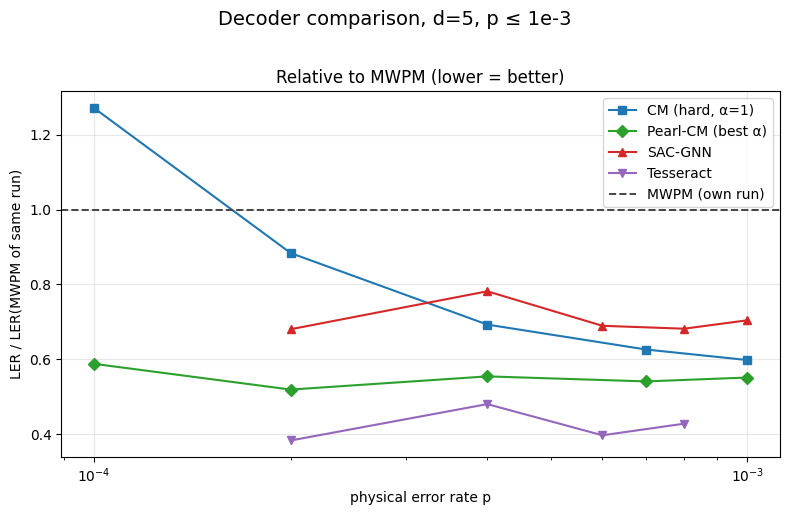

saved plots/decoder_comparison_d5.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
STY = {"MWPM": ("#444444", "--o"), "CM (hard, α=1)": ("#1f77b4", "-s"),
       "Pearl-CM (best α)": ("#2ca02c", "-D"), "SAC-GNN": ("#d62728", "-^"),
       "Tesseract": ("#9467bd", "-v")}
# ---- (1) raw LER vs p ----
'''
def eb(a, x, arr, name):
    c, mk = STY[name]
    a.errorbar(x, arr[:, 0], yerr=arr[:, 1], fmt=mk, color=c, ms=6, lw=1.7, capsize=2, label=name)
eb(ax[0], ps_a, mwpm, "MWPM")
eb(ax[0], ps_a, cm, "CM (hard, α=1)")
eb(ax[0], ps_a, pearl, "Pearl-CM (best α)")
eb(ax[0], ps_g, gnn, "SAC-GNN")
eb(ax[0], ps_t, tess, "Tesseract")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("physical error rate p"); ax[0].set_ylabel("logical error rate")
ax[0].set_title("Raw LER vs p (d=5)"); ax[0].legend(); ax[0].grid(alpha=0.3, which="both")
'''
# ---- (2) LER / own-run MWPM (fair cross-run comparison) ----
ax.plot(ps_a, cm[:, 0] / mwpm[:, 0], "-s", color=STY["CM (hard, α=1)"][0], ms=6, label="CM (hard, α=1)")
ax.plot(ps_a, pearl[:, 0] / mwpm[:, 0], "-D", color=STY["Pearl-CM (best α)"][0], ms=6, label="Pearl-CM (best α)")
ax.plot(ps_g, gnn[:, 0] / gnn_mwpm, "-^", color=STY["SAC-GNN"][0], ms=6, label="SAC-GNN")
ax.plot(ps_t, tess[:, 0] / tess_mwpm, "-v", color=STY["Tesseract"][0], ms=6, label="Tesseract")
ax.axhline(1.0, color="#444444", ls="--", lw=1.4, label="MWPM (own run)")
ax.set_xscale("log")
ax.set_xlabel("physical error rate p"); ax.set_ylabel("LER / LER(MWPM of same run)")
ax.set_title("Relative to MWPM (lower = better)"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Decoder comparison, d=5, p ≤ 1e-3", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "decoder_comparison_d5.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/decoder_comparison_d5.png")

In [3]:
# Numeric table of LER / own-MWPM at the shared low-p points
print(f"{'p':>8} | {'CM/MWPM':>8} {'Pearl/MWPM':>10} {'SACGNN/MWPM':>11} {'Tess/MWPM':>9}")
def near(xs, ys, p):
    i = int(np.argmin(np.abs(xs - p))); return ys[i] if abs(xs[i]-p) < p*0.4 else np.nan
for p in ps_a:
    rc = cm[list(ps_a).index(p), 0] / mwpm[list(ps_a).index(p), 0]
    rp = pearl[list(ps_a).index(p), 0] / mwpm[list(ps_a).index(p), 0]
    rg = near(ps_g, gnn[:, 0] / gnn_mwpm, p)
    rt = near(ps_t, tess[:, 0] / tess_mwpm, p)
    print(f"{p:>8.0e} | {rc:>8.3f} {rp:>10.3f} {rg:>11.3f} {rt:>9.3f}")

       p |  CM/MWPM Pearl/MWPM SACGNN/MWPM Tess/MWPM
   1e-04 |    1.272      0.588         nan       nan
   2e-04 |    0.884      0.519       0.680     0.383
   4e-04 |    0.693      0.554       0.782     0.480
   7e-04 |    0.626      0.541       0.690     0.397
   1e-03 |    0.598      0.551       0.704     0.428


## Notes

- **Tesseract is the floor** (near-ML, search-based) — lowest LER, best ratio. It's the practical target the other decoders are chasing.
- **Pearl-CM (best α) is the closest analytic decoder to Tesseract**, and beats both hard CM and the SAC-GNN in this low-p range. (Recall best-α is an *oracle* over α per p; a single fixed α would be a bit worse.)
- **Hard CM (α=1) degrades toward low p** — its ratio to MWPM rises as p→0 (over-correction), approaching / exceeding 1 near 1e-4, while Pearl-CM and the others keep improving.
- **SAC-GNN beats MWPM everywhere and beats hard CM at the lowest p**, but sits above Pearl-CM here.
- **Caveat (repeat):** the raw-LER panel overlays three separate runs whose MWPM baselines differ by up to ~20% (e.g. at 4e-4). The ratio panel removes that by normalising each decoder to its own run's MWPM — trust the ratio panel for the head-to-head ordering.